In [2]:
import os
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, GlobalAveragePooling2D, Dense


# EDA & Cleaning

1. PENGHAPUSAN DUPLIKAT BERDASARKAN COSINE SIMILARITY (CSV)
Membaca duplicates_0_Recyclable.csv untuk folder '0_Recyclable'...
 -> Berhasil menghapus 0 gambar dari '0_Recyclable'
Membaca duplicates_1_Electronic.csv untuk folder '1_Electronic'...
 -> Berhasil menghapus 0 gambar dari '1_Electronic'
Membaca duplicates_2_Organic.csv untuk folder '2_Organic'...
 -> Berhasil menghapus 0 gambar dari '2_Organic'

✅ Total gambar duplikat visual yang dibasmi: 0

2. EXPLORATORY DATA ANALYSIS (EDA)
Kelas '0_Recyclable' memiliki: 9932 gambar bersih.
Kelas '1_Electronic' memiliki: 3855 gambar bersih.
Kelas '2_Organic' memiliki: 12466 gambar bersih.


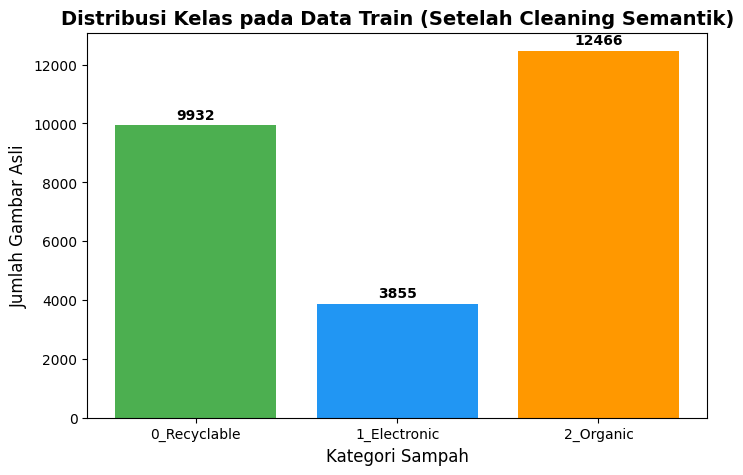

In [5]:
# 1. Tentukan path folder train dan file CSV milikmu
TRAIN_DIR = "data/train" # Sesuaikan path folder train
CSV_PATH_RECYCLABLE = "duplicates_0_Recyclable.csv" # Sesuaikan path file CSV
CSV_PATH_ELECTRONIC = "duplicates_1_Electronic.csv" # Sesuaikan path file CSV
CSV_PATH_ORGANIC = "duplicates_2_Organic.csv"       # Sesuaikan path file CSV

# Membuat pemetaan (mapping) antara nama folder dan file CSV-nya
csv_mapping = {
    '0_Recyclable': CSV_PATH_RECYCLABLE,
    '1_Electronic': CSV_PATH_ELECTRONIC,
    '2_Organic': CSV_PATH_ORGANIC
}

print("="*50)
print("1. PENGHAPUSAN DUPLIKAT BERDASARKAN COSINE SIMILARITY (CSV)")
print("="*50)

total_terhapus = 0

# Berjalan menyusuri 3 kelas folder kita
for class_folder, csv_file in csv_mapping.items():
    class_path = os.path.join(TRAIN_DIR, class_folder)
    
    # Memastikan file CSV dan foldernya ada
    if os.path.exists(class_path) and os.path.exists(csv_file):
        print(f"Membaca {csv_file} untuk folder '{class_folder}'...")
        
        # Membaca data menggunakan Pandas
        df_duplicates = pd.read_csv(csv_file)
        
        # Mengambil daftar nama file di kolom Image_B untuk dihapus
        images_to_delete = df_duplicates['Image_B'].tolist()
        
        terhapus_di_kelas_ini = 0
        for img_name in images_to_delete:
            img_path = os.path.join(class_path, img_name)
            
            # Jika file fisiknya ada, maka hapus!
            if os.path.exists(img_path):
                os.remove(img_path)
                terhapus_di_kelas_ini += 1
                total_terhapus += 1
                
        print(f" -> Berhasil menghapus {terhapus_di_kelas_ini} gambar dari '{class_folder}'")
    else:
        print(f"⚠️ Peringatan: Folder {class_folder} atau file {csv_file} tidak ditemukan. Pastikan path-nya benar!")

print(f"\n✅ Total gambar duplikat visual yang dibasmi: {total_terhapus}")


print("\n" + "="*50)
print("2. EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

# Fungsi EDA (Sama persis seperti sebelumnya)
def plot_class_distribution(directory):
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    counts = []
    
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        num_images = len(os.listdir(cls_path))
        counts.append(num_images)
        print(f"Kelas '{cls}' memiliki: {num_images} gambar bersih.")
        
    plt.figure(figsize=(8, 5))
    bars = plt.bar(classes, counts, color=['#4CAF50', '#2196F3', '#FF9800'])
    plt.title('Distribusi Kelas pada Data Train (Setelah Cleaning Semantik)', fontsize=14, fontweight='bold')
    plt.xlabel('Kategori Sampah', fontsize=12)
    plt.ylabel('Jumlah Gambar Asli', fontsize=12)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.01), int(yval), ha='center', va='bottom', fontweight='bold')
        
    plt.show()

# Jalankan fungsi EDA
plot_class_distribution(TRAIN_DIR)

In [6]:
# 1. Menentukan bobot kelas berdasarkan hasil grafik EDA
total_data = 12053 + 1475 + 9445
jumlah_kelas = 3

class_weight_dict = {
    0: (1 / 12053) * (total_data / jumlah_kelas), # Recyclable
    1: (1 / 1475) * (total_data / jumlah_kelas),  # Electronic (Sangat butuh perhatian)
    2: (1 / 9445) * (total_data / jumlah_kelas)   # Organic
}

print("Bobot yang diberikan pada masing-masing kelas:")
for key, value in class_weight_dict.items():
    print(f"Kelas {key}: {value:.2f}")

Bobot yang diberikan pada masing-masing kelas:
Kelas 0: 0.64
Kelas 1: 5.19
Kelas 2: 0.81


# Pembagian Data

In [7]:
# 1. Tentukan parameter dasar
BATCH_SIZE = 32
IMG_SIZE = (224, 224) 
TRAIN_DIR = "data/train" # Sesuaikan dengan path folder train milikmu

print("Memuat Data Training (80%)...")
# Memuat dataset untuk Training (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,    
    subset="training",       
    seed=123,                
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' 
)

print("\nMemuat Data Sementara (20%)...")
# Memuat sisa 20% data sementara untuk nanti dibelah lagi
temp_val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",     
    seed=123,                
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Mengekstrak nama kelas
class_names = train_dataset.class_names
print(f"\nKelas yang berhasil dideteksi: {class_names}")

print("\nMembelah data 20% menjadi 10% Validation dan 10% Local Test...")
# Menghitung jumlah batch pada data 20%
val_batches = tf.data.experimental.cardinality(temp_val_dataset)

# Mengambil 50% dari batch tersebut untuk Validation (10% dari total data)
validation_dataset = temp_val_dataset.take(val_batches // 2)

# Melewati 50% batch awal dan mengambil sisanya untuk Local Test (10% dari total data)
local_test_dataset = temp_val_dataset.skip(val_batches // 2)

print(f"-> Batch untuk Validation: {tf.data.experimental.cardinality(validation_dataset)} batch")
print(f"-> Batch untuk Local Test: {tf.data.experimental.cardinality(local_test_dataset)} batch")

# Optimasi performa pembacaan data
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
local_test_dataset = local_test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Memuat Data Training (80%)...
Found 26253 files belonging to 3 classes.
Using 21003 files for training.

Memuat Data Sementara (20%)...
Found 26253 files belonging to 3 classes.
Using 5250 files for validation.

Kelas yang berhasil dideteksi: ['0_Recyclable', '1_Electronic', '2_Organic']

Membelah data 20% menjadi 10% Validation dan 10% Local Test...
-> Batch untuk Validation: 82 batch
-> Batch untuk Local Test: 83 batch


In [8]:
# 1. Membuat Pipeline Data Augmentation
# Menginstruksikan komputer untuk secara acak memutar, membalik, atau memperbesar gambar
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
], name="data_augmentation")

# 2. Memuat Base Model (MobileNetV2) sebagai Feature Extractor
IMG_SHAPE = (224, 224, 3)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False, # Membuang layer klasifikasi bawaan dari model aslinya
    weights='imagenet' # Menggunakan kecerdasan yang sudah dilatih dari jutaan gambar
)

# Membekukan (freeze) base model agar pengetahuan awalnya tidak rusak saat awal training
base_model.trainable = False

# 3. Merangkai Semuanya Menjadi Satu Model Utuh
model = Sequential([
    tf.keras.Input(shape=IMG_SHAPE), # Input layer sesuai ukuran gambar kita
    data_augmentation, # Proses augmentasi (Secara otomatis hanya aktif saat proses training)
    Rescaling(1./255), # Rescaling: Menormalisasi piksel dari rentang 0-255 menjadi 0-1
    base_model, # Ekstraksi fitur menggunakan kecerdasan MobileNetV2
    GlobalAveragePooling2D(), # Mengubah matriks fitur yang rumit menjadi vektor 1D yang ringkas

    # Classification Head: Lapisan klasifikasi akhir
    # Menggunakan 3 neuron untuk menebak kelas Recyclable, Electronic, atau Organic
    Dense(3, activation='softmax', name="output_layer")
])

# Melihat ringkasan arsitektur yang baru saja dibuat
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# 1. Konfigurasi Model (Compile)
print("Mengonfigurasi Model...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Menggunakan Adam optimizer (standar terbaik saat ini)
    loss='categorical_crossentropy',                         # Karena kita punya 3 kelas dan pakai 'categorical' label_mode
    metrics=['accuracy']                                     # Metrik dasar yang dipantau selama training berjalan
)

# 2. Proses Pelatihan (Training / Fit)
# Kita mulai dengan 10 putaran (Epoch) dulu untuk melihat perkembangannya
EPOCHS = 10

print(f"\nMemulai proses training selama {EPOCHS} Epochs...")
# Di tahap inilah model mulai "menyedot" batch gambar dan memakan waktu yang cukup lama
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weight_dict
)

Mengonfigurasi Model...

Memulai proses training selama 10 Epochs...
Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 286s 361ms/step - accuracy: 0.8037 - loss: 0.4595 - val_accuracy: 0.8792 - val_loss: 0.3232
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 235s 358ms/step - accuracy: 0.8611 - loss: 0.3441 - val_accuracy: 0.8712 - val_loss: 0.3541
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 237s 361ms/step - accuracy: 0.8670 - loss: 0.3280 - val_accuracy: 0.8784 - val_loss: 0.3301
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 234s 356ms/step - accuracy: 0.8696 - loss: 0.3187 - val_accuracy: 0.8929 - val_loss: 0.2841
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 239s 364ms/step - accuracy: 0.8767 - loss: 0.3111 - val_accuracy: 0.9051 - val_loss: 0.2587
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 182s 276ms/step - accuracy: 0.8773 - loss: 0.2969 - val_accuracy: 0.8941 - val_loss: 0.2929
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 140s 212ms/step - accuracy: 0.8785 - loss: 0.2993 - val_accuracy: 0.9021 - val_loss: 0.2768
Epoch 8

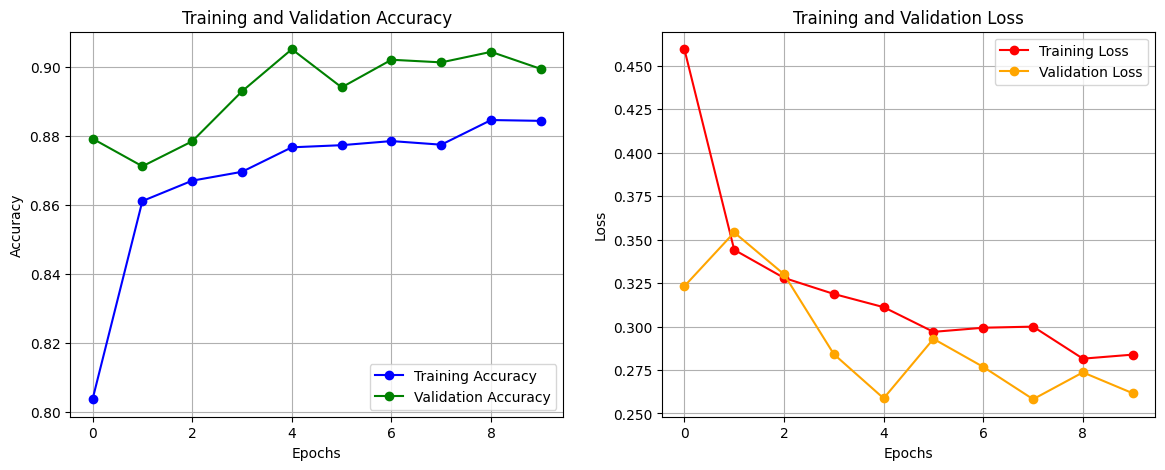

In [10]:
# 1. Mengekstrak nilai dari variabel history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Menyesuaikan dengan jumlah Epoch yang berjalan
epochs_range = range(len(acc))

# 2. Membuat kanvas grafik
plt.figure(figsize=(14, 5))

# --- Grafik Akurasi ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='green', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

# --- Grafik Loss (Kesalahan) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Menampilkan grafik
plt.show()

In [11]:
from sklearn.metrics import classification_report

print("Mengevaluasi model menggunakan Local Test Dataset (10%)...")

y_true = []
y_pred_probs = []

# Melakukan iterasi ke seluruh batch pada local_test_dataset
for images, labels in local_test_dataset:
    # Model melakukan prediksi pada batch gambar
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    
    # Mengambil label asli (mengubah dari format categorical/one-hot kembali ke angka indeks)
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Mengubah hasil probabilitas tebakan menjadi angka kelas akhir (0, 1, atau 2)
y_pred = np.argmax(y_pred_probs, axis=1)

# Mencetak Classification Report dari Scikit-Learn
print("\n" + "="*50)
print("     CLASSIFICATION REPORT & MACRO F1-SCORE")
print("="*50)
report = classification_report(
    y_true, 
    y_pred, 
    target_names=class_names, 
    digits=4 # Menampilkan 4 angka di belakang koma agar presisi
)
print(report)

Mengevaluasi model menggunakan Local Test Dataset (10%)...

     CLASSIFICATION REPORT & MACRO F1-SCORE
              precision    recall  f1-score   support

0_Recyclable     0.8780    0.9143    0.8958       992
1_Electronic     0.8673    0.9464    0.9051       373
   2_Organic     0.9612    0.9040    0.9318      1261

    accuracy                         0.9139      2626
   macro avg     0.9022    0.9216    0.9109      2626
weighted avg     0.9165    0.9139    0.9144      2626



In [12]:
# 1. Tentukan path folder di Google Drive tempat kamu ingin menyimpan model
SAVE_MODEL_PATH = 'trash_classification.keras'

print("Sedang menyimpan model ke Google Drive... Harap tunggu...")
# 2. Perintah sakti untuk menyimpan seluruh arsitektur dan bobot model
model.save(SAVE_MODEL_PATH)

print(f"🎉 Mantap bro! Model cerdasmu sudah aman tersimpan di: {SAVE_MODEL_PATH}")

Sedang menyimpan model ke Google Drive... Harap tunggu...
🎉 Mantap bro! Model cerdasmu sudah aman tersimpan di: trash_classification.keras


In [13]:
LOAD_MODEL_PATH = 'trash_classification.keras'
training_model = tf.keras.models.load_model(LOAD_MODEL_PATH)

# 1. Tentukan Path
TEST_DIR = 'data/test' # Sesuaikan path folder test
CSV_TEMPLATE_PATH = 'submission.csv'

# 2. Membaca file template asli (Kita pegang strukturnya erat-erat)
submission_df = pd.read_csv(CSV_TEMPLATE_PATH)

# 3. Memuat Data Test
print("Memuat Data Test...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels=None,
    label_mode=None,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False       # Sangat penting agar program membacanya berurutan
)

# 4. Mengeksekusi Prediksi
print("\nModel sedang menebak gambar pada data test. Harap tunggu...")
predictions = training_model.predict(test_dataset)

# Mengubah probabilitas menjadi angka kelas (0, 1, atau 2)
predicted_classes = np.argmax(predictions, axis=1)

# 5. Mengekstrak 'id' dari nama file gambar untuk dicocokkan
# (Misalnya gambar bernama "1.jpg" akan diambil angka 1-nya saja)
file_ids = [int(os.path.splitext(os.path.basename(path))[0]) for path in test_dataset.file_paths]

# 6. KUNCI UTAMA: Membuat kamus pemetaan (Dictionary Mapping)
# Program akan mengingat: ID 1 tebakannya 0, ID 2 tebakannya 2, dst.
pred_dict = dict(zip(file_ids, predicted_classes))

# 7. MENGISI CSV ASLI TANPA MERUSAK STRUKTUR
# Kita isi kolom 'predicted' murni berdasarkan kecocokan kolom 'id'
submission_df['predicted'] = submission_df['id'].map(pred_dict)

# 8. Menyimpan Hasil Akhir
FINAL_CSV_PATH = 'Submission_Satria Ancol.csv'
submission_df.to_csv(FINAL_CSV_PATH, index=False)

print("file submission sudah tersimpan")

Memuat Data Test...
Found 1458 files.

Model sedang menebak gambar pada data test. Harap tunggu...
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step
file submission sudah tersimpan
